In [1]:
# IMDb Movie Ratings Analysis Project

# 1. Importing Necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# 2. Loading Dataset

df = pd.read_csv(r"C:\Users\khani\Downloads\archive\imdb_top_1000.csv", encoding='latin1')

In [10]:
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [11]:
# 3. Exploring Dataset

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   str    
 3   Certificate    899 non-null    str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    str    
dtypes: float64(2), int64(1), str(13)
memory usage: 125.1 KB


Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

In [31]:
# 4. Data Cleaning

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

In [15]:
# 5. Summary Statistics of IMDb Ratings

print("Mean Rating:", df['IMDB_Rating'].mean())

print("Median Rating:", df['IMDB_Rating'].median())

print("Mode Rating:", df['IMDB_Rating'].mode()[0])

Mean Rating: 7.937114845938376
Median Rating: 7.9
Mode Rating: 7.7


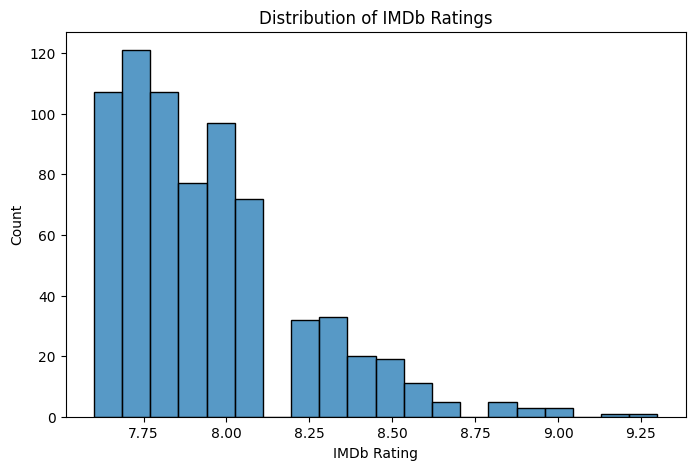

In [16]:
# 6. Distribution of IMDb Ratings

plt.figure(figsize=(8,5))

sns.histplot(df['IMDB_Rating'], bins=20)

plt.title("Distribution of IMDb Ratings")

plt.xlabel("IMDb Rating")

plt.ylabel("Count")

plt.show()

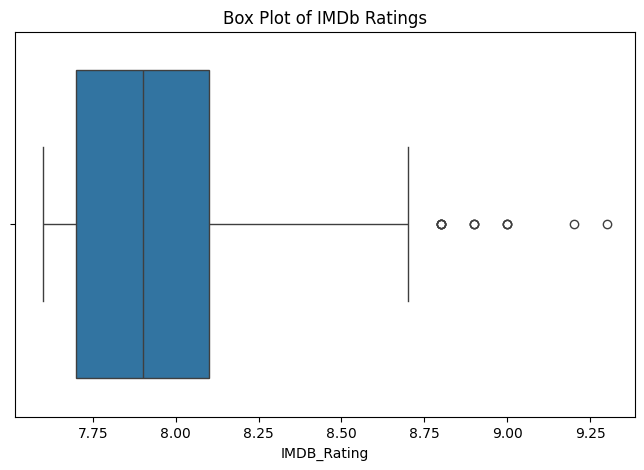

In [17]:
# 7. Box Plot of Ratings

plt.figure(figsize=(8,5))

sns.boxplot(x=df['IMDB_Rating'])

plt.title("Box Plot of IMDb Ratings")

plt.show()

In [18]:
# 8. Top Rated Movies

top_movies = df.sort_values(by='IMDB_Rating', ascending=False)

print(top_movies[['Series_Title', 'IMDB_Rating']].head(10))

                                    Series_Title  IMDB_Rating
0                       The Shawshank Redemption          9.3
1                                  The Godfather          9.2
2                                The Dark Knight          9.0
3                         The Godfather: Part II          9.0
4                                   12 Angry Men          9.0
5  The Lord of the Rings: The Return of the King          8.9
6                                   Pulp Fiction          8.9
7                               Schindler's List          8.9
8                                      Inception          8.8
9                                     Fight Club          8.8


In [19]:
# 9. Genre Analysis

genre_rating = df.groupby('Genre')['IMDB_Rating'].mean().sort_values(ascending=False)

print(genre_rating.head(10))

Genre
Crime, Mystery, Thriller        8.50
Action, Sci-Fi                  8.40
Drama, Horror                   8.40
Horror, Sci-Fi                  8.40
Drama, Mystery, War             8.35
Western                         8.35
Adventure, Mystery, Thriller    8.30
Mystery, Romance, Thriller      8.30
Comedy, Musical, Romance        8.30
Crime, Drama, Sci-Fi            8.30
Name: IMDB_Rating, dtype: float64


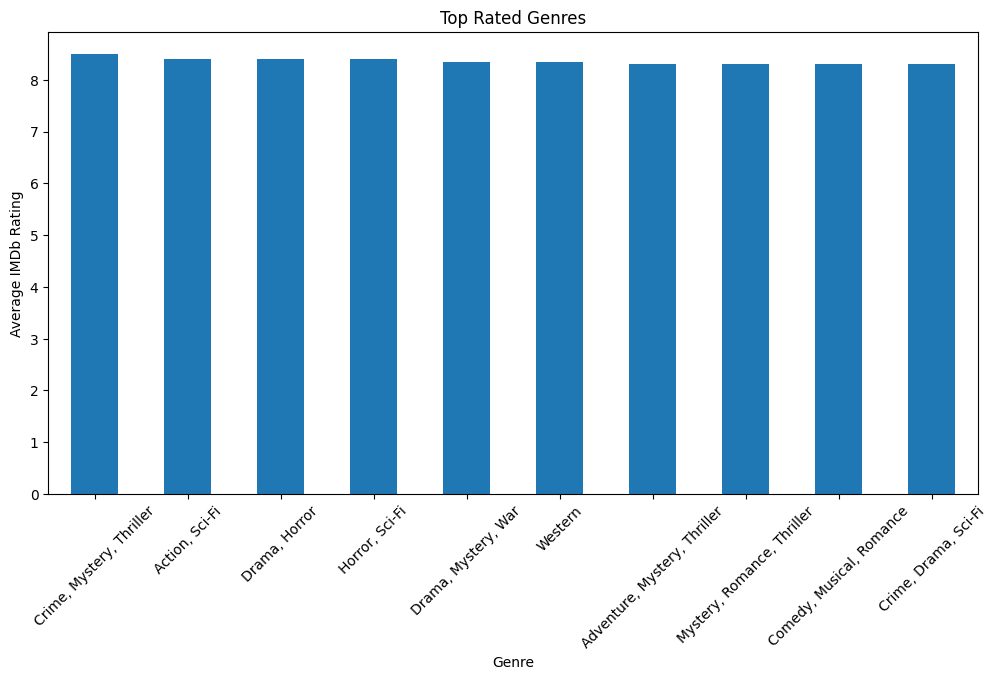

In [20]:
# 10. Genre Visualization

plt.figure(figsize=(12,6))

genre_rating.head(10).plot(kind='bar')

plt.title("Top Rated Genres")

plt.xlabel("Genre")

plt.ylabel("Average IMDb Rating")

plt.xticks(rotation=45)

plt.show()

In [28]:
# 11. Search Any Movie

movie = df[df['Series_Title'].str.contains("Joker", case=False)]

print(movie[['Series_Title', 'IMDB_Rating', 'Genre']])

   Series_Title  IMDB_Rating                   Genre
33        Joker          8.5  Crime, Drama, Thriller


In [30]:
# Conclusion:
# - Most movies are rated between 7 and 8.
# - Drama and Crime genres are highly rated.
# - IMDb ratings have a balanced distribution.
# - The dataset includes many critically acclaimed movies.